In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
from torch import nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
trainData = datasets.CIFAR10(
    root="../data", 
    train=True, 
    transform=ToTensor(), 
    download=True,
    target_transform=None
)

testData = datasets.CIFAR10(
    root="../data", 
    train=False, 
    transform=ToTensor(), 
    download=True,
    target_transform=None
)

In [3]:
image, label = trainData[0]
print(f"Image shape: {image.shape} | Label: {label}")

Image shape: torch.Size([3, 32, 32]) | Label: 6


In [4]:
classNames = trainData.classes
print(f"There are {len(classNames)} classes. Class names: {classNames}")


There are 10 classes. Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Text(0.5, 1.0, 'frog')

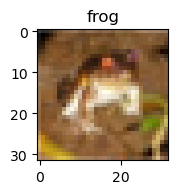

In [5]:
plt.figure(figsize=(1.7, 1.7))
plt.imshow(image.permute(1, 2, 0))
plt.title(classNames[label])

In [6]:
from torchvision import transforms

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2471, 0.2435, 0.2616])
])

In [8]:
trainData = datasets.CIFAR10(
    root="../data", 
    train=True, 
    transform=transform, 
    download=True,
    target_transform=None
)

testData = datasets.CIFAR10(
    root="../data", 
    train=False, 
    transform=transform, 
    download=True,
    target_transform=None
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9886686..2.0942786].


Text(0.5, 1.0, 'frog')

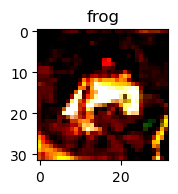

In [9]:
image, label = trainData[0]

plt.figure(figsize=(1.7, 1.7))
plt.imshow(image.permute(1, 2, 0))
plt.title(classNames[label])

In [10]:
from torch.utils.data import DataLoader

In [11]:
BATCH_SIZE = 32
trainDataloader = DataLoader(trainData, batch_size=BATCH_SIZE, shuffle=True)
testDataloader = DataLoader(testData, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
print(f"Number of batches in train dataloader: {len(trainDataloader)}")

Number of batches in train dataloader: 1563


In [13]:
1563 * 32 # We have 32 batches and each batch has 1563 sample. Total of 50016 samples in the training dataset.

50016

In [14]:
class CIFAR10ClassifierCNN(nn.Module):

    def __init__(self, inputShape: int, hiddenUnits: int, outputShape: int) -> None:
        super().__init__()

        self.firstBlock = nn.Sequential(
            nn.Conv2d(in_channels=inputShape, out_channels=hiddenUnits, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hiddenUnits, out_channels=hiddenUnits, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.secondBlock = nn.Sequential(
            nn.Conv2d(in_channels=hiddenUnits, out_channels=hiddenUnits, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hiddenUnits, out_channels=hiddenUnits, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hiddenUnits*8*8, out_features=outputShape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(
            self.secondBlock(
                self.firstBlock(x)
            )
        )

In [15]:
torch.manual_seed(42)
classCount = len(classNames)

model = CIFAR10ClassifierCNN(inputShape=3, hiddenUnits=10, outputShape=classCount)


In [16]:
model

CIFAR10ClassifierCNN(
  (firstBlock): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (secondBlock): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=640, out_features=10, bias=True)
  )
)

In [17]:
model = torch.compile(model, backend="cudagraphs")

In [18]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [19]:
def calculate_accuracy(y_true, y_pred):
    return (torch.eq(y_true, y_pred).sum().item() / len(y_pred)) * 100

In [20]:
torch.manual_seed(42)

epochs = 5

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for batch, (X, y) in enumerate(trainDataloader):

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 == 0:
            print(f"Epoch: {epoch} | Batch: {batch} | Loss: {loss:.4f}")

    train_loss /= len(trainDataloader)

    test_loss = 0
    test_acc = 0

    model.eval()
    with torch.inference_mode():
        
        for X, y in testDataloader:
            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += calculate_accuracy(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(testDataloader)
        test_acc /= len(testDataloader)

    print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

skipping cudagraphs due to skipping cudagraphs due to cpu device (primals_1). Found from : 
   File "C:\Users\1\AppData\Local\Temp\ipykernel_11108\2571057436.py", line 30, in forward
    self.firstBlock(x)
  File "c:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\container.py", line 253, in forward
    input = module(input)
  File "c:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\conv.py", line 553, in forward
    return self._conv_forward(input, self.weight, self.bias)
  File "c:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\conv.py", line 548, in _conv_forward
    return F.conv2d(



Epoch: 0 | Batch: 0 | Loss: 2.3041
Epoch: 0 | Batch: 500 | Loss: 1.3082
Epoch: 0 | Batch: 1000 | Loss: 1.4361
Epoch: 0 | Batch: 1500 | Loss: 1.0951


skipping cudagraphs due to skipping cudagraphs due to cpu device (primals_1). Found from : 
   File "C:\Users\1\AppData\Local\Temp\ipykernel_11108\2571057436.py", line 30, in forward
    self.firstBlock(x)
  File "c:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\container.py", line 253, in forward
    input = module(input)
  File "c:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\conv.py", line 553, in forward
    return self._conv_forward(input, self.weight, self.bias)
  File "c:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\conv.py", line 548, in _conv_forward
    return F.conv2d(

skipping cudagraphs due to skipping cudagraphs due to cpu device (arg0_1). Found from : 
   File "C:\Users\1\AppData\Local\Temp\ipykernel_11108\2571057436.py", line 30, in forward
    self.firstBlock(x)
  File "c:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\container.py", line 253, in forward
    input = module(input)
  File "c:\ProgramData\anaconda3\Lib\site-pa

Epoch: 0 | Train Loss: 1.5471 | Test Loss: 1.3210 | Test Accuracy: 52.3762
Epoch: 1 | Batch: 0 | Loss: 1.1116
Epoch: 1 | Batch: 500 | Loss: 1.2007
Epoch: 1 | Batch: 1000 | Loss: 1.2770
Epoch: 1 | Batch: 1500 | Loss: 1.0793
Epoch: 1 | Train Loss: 1.2435 | Test Loss: 1.1817 | Test Accuracy: 57.7975
Epoch: 2 | Batch: 0 | Loss: 1.3796
Epoch: 2 | Batch: 500 | Loss: 1.2882
Epoch: 2 | Batch: 1000 | Loss: 1.0023
Epoch: 2 | Batch: 1500 | Loss: 0.7832
Epoch: 2 | Train Loss: 1.1322 | Test Loss: 1.1089 | Test Accuracy: 60.6130
Epoch: 3 | Batch: 0 | Loss: 1.3495
Epoch: 3 | Batch: 500 | Loss: 0.9467
Epoch: 3 | Batch: 1000 | Loss: 1.0754
Epoch: 3 | Batch: 1500 | Loss: 1.1576
Epoch: 3 | Train Loss: 1.0591 | Test Loss: 1.0699 | Test Accuracy: 62.4401
Epoch: 4 | Batch: 0 | Loss: 1.1188
Epoch: 4 | Batch: 500 | Loss: 0.6721
Epoch: 4 | Batch: 1000 | Loss: 1.0209
Epoch: 4 | Batch: 1500 | Loss: 1.1538
Epoch: 4 | Train Loss: 1.0110 | Test Loss: 1.0722 | Test Accuracy: 61.6214


In [21]:
def evaluate_model(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn):
    loss = 0
    accuracy = 0

    model.eval()
    with torch.inference_mode():
        for X, y in dataloader:
            test_pred = model(X)
            loss += loss_fn(test_pred, y).item()
            accuracy += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))  
        
        loss /= len(dataloader)
        accuracy /= len(dataloader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss,
        "model_accuracy": accuracy
    }

    
    

In [22]:
model_results = evaluate_model(model=model, dataloader=testDataloader, loss_fn=loss_fn, accuracy_fn=calculate_accuracy)

In [23]:
model_results

{'model_name': 'OptimizedModule',
 'model_loss': 1.0722317922229585,
 'model_accuracy': 61.62140575079872}

In [24]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # each [C, H, W]
    return: [N, num_classes] probability tensor
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Take Logits 
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Turn into probabilities with Softmax
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Squeeze batch dimension
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Combine all into one tensor → [N, num_classes]
    return torch.stack(pred_probs)

In [25]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # choose n random indices from the dataset
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # prepare the image for the model
            img_input = img.unsqueeze(0)  
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # permute for visualization
            img_show = img.permute(1, 2, 0)

            # true or false?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

skipping cudagraphs due to skipping cudagraphs due to cpu device (arg0_1). Found from : 
   File "C:\Users\1\AppData\Local\Temp\ipykernel_11108\2571057436.py", line 30, in forward
    self.firstBlock(x)
  File "c:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\container.py", line 253, in forward
    input = module(input)
  File "c:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\conv.py", line 553, in forward
    return self._conv_forward(input, self.weight, self.bias)
  File "c:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\conv.py", line 548, in _conv_forward
    return F.conv2d(

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9480774..1.7408686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9886686..1.950928].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..2

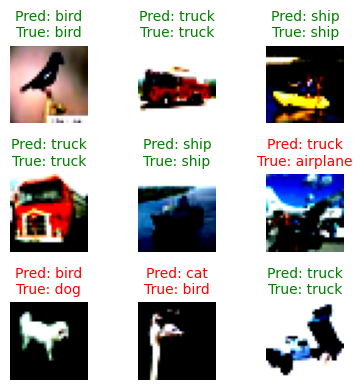

In [26]:
show_random_predictions(model, testData, class_names=classNames)